# Splice site evaluation over a BED file

Runs splice-site classification predictions over all (or a subset of) windows
defined by a BED file and aggregates AUPRC, confusion counts, and PR curves
across the full set.

## Configuration

In [6]:
# ── Paths ──────────────────────────────────────────────────────────────────
genome      = "/home/elek/sds/sd17d003/Anamaria/genomes/ensembl115/fasta/Homo_sapiens.fa"
bed_file    = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/folds_100kb/FOLD_0_subset/test.bed"
annotation  = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/splice_sites.parquet"
usage_file  = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/usage.parquet"
checkpoint  = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/00/132kb_lora/best_model.pth"

# ── Settings ────────────────────────────────────────────────────────────────
device      = "cuda"
organism    = 0          # 0 = human, 1 = mouse
seq_len     = 131072
max_windows = 100         # set to None to run all windows in the BED file

# ── Labels / colours (shared across cells) ─────────────────────────────────
SPLICE_CLASS_NAMES = ["Donor+", "Acceptor+", "Donor-", "Acceptor-"]
BACKGROUND_CLASS   = 4
CLASS_LABELS  = {0: 'donor +', 1: 'acceptor +', 2: 'donor -', 3: 'acceptor -', 4: 'no splice site'}
CLASS_COLORS  = {0: '#ff7f00', 1: '#33a02c', 2: '#fdbf6f', 3: '#b2df8a', 4: '#1f78b4'}

## Load model and annotations

In [7]:
import numpy as np
import pandas as pd
import torch
from alphagenome_pytorch.utils.model_loading import load_model_for_inference

model, cfg = load_model_for_inference(checkpoint, device, strict=False)
model.eval()
print(f"Model loaded from: {checkpoint}")

Model loaded from: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/00/132kb_lora/best_model.pth


In [8]:

# Verify finetuned weights are loaded (spot-check one classification head parameter)
import hashlib
head_params = list(model.splice_sites_classification_head.parameters())
param_sum = sum(p.sum().item() for p in head_params)
print(f"Splice head parameter sum: {param_sum:.4f}")
print(f"  (pretrained baseline is ~0; finetuned will differ)")
print(f"Config mode: {cfg.get('mode') if cfg else 'N/A (pretrained path)'}")
print(f"Checkpoint: {checkpoint}")


Splice head parameter sum: -35.1927
  (pretrained baseline is ~0; finetuned will differ)
Config mode: lora
Checkpoint: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/00/132kb_lora/best_model.pth


In [9]:
import pyfaidx
from alphagenome_pytorch.utils.sequence import sequence_to_onehot

fasta   = pyfaidx.Fasta(genome, as_raw=True, sequence_always_upper=True)
annot   = pd.read_parquet(annotation)
annot["Chromosome"] = annot["Chromosome"].astype(str)
usage   = pd.read_parquet(usage_file)

# Read BED windows
half = seq_len // 2
windows = []
with open(bed_file) as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue
        parts = line.strip().split()
        chrom  = parts[0]
        center = (int(parts[1]) + int(parts[2])) // 2
        windows.append((chrom, center - half, center + half))

if max_windows is not None:
    windows = windows[:max_windows]

print(f"Loaded {len(windows)} windows from {bed_file}")

Loaded 100 windows from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/folds_100kb/FOLD_0_subset/test.bed


## Run inference

In [ ]:
from sklearn.metrics import average_precision_score, precision_recall_curve
from alphagenome_pytorch.utils.sequence import sequence_to_onehot
from tqdm.auto import tqdm

# Label mapping: SiteType string → class index
label_to_idx = {name: i for i, name in enumerate(SPLICE_CLASS_NAMES)}
n_classes = len(SPLICE_CLASS_NAMES) + 1  # 4 splice + 1 background

# Organism tensor (re-used every iteration)
org_t = torch.full((1,), organism, dtype=torch.long, device=device)

all_probs        = []   # list of (L, n_classes) arrays for all positions
all_true_classes = []   # list of (L,) int arrays for all positions
all_alphas       = []   # list of dicts {alpha, correct}

model.eval()
with torch.no_grad():
    for chrom_w, start_w, end_w in tqdm(windows, desc="Windows"):
        # ── Extract and encode sequence ────────────────────────────────
        try:
            seq = fasta[chrom_w][start_w:end_w]
        except Exception:
            continue
        if len(seq) != seq_len:
            continue
        seq_np = sequence_to_onehot(seq).astype(np.float32)   # (L, 4)
        seq_t  = torch.from_numpy(seq_np).unsqueeze(0).to(device)  # (1, L, 4)

        # ── Predict ────────────────────────────────────────────────────
        out   = model.predict(seq_t, org_t, resolutions=(1,))
        probs = out["splice_sites_classification"]["probs"][0].cpu().numpy()  # (L, n_classes)

        # ── Build ground-truth class labels for this window ───────────
        chrom_str = str(chrom_w)
        w_annot = annot[
            (annot["Chromosome"] == chrom_str) &
            (annot["Position"] >= start_w) &
            (annot["Position"] <  end_w)
        ]

        true_classes = np.full(seq_len, BACKGROUND_CLASS, dtype=np.int64)
        for _, row in w_annot.iterrows():
            rel_pos = int(row["Position"]) - start_w
            if 0 <= rel_pos < seq_len:
                true_classes[rel_pos] = label_to_idx.get(row["SiteType"], BACKGROUND_CLASS)

        all_probs.append(probs)
        all_true_classes.append(true_classes)

        # ── Optional: collect usage alphas for true sites only ────────
        w_usage = usage[
            (usage["Chromosome"] == chrom_str) &
            (usage["Position"] >= start_w) &
            (usage["Position"] <  end_w)
        ]
        for _, row in w_usage.iterrows():
            rel = int(row["Position"]) - start_w
            if 0 <= rel < seq_len and true_classes[rel] != BACKGROUND_CLASS:
                pred_cls = int(np.argmax(probs[rel]))
                all_alphas.append({"alpha":   row.get("Alpha", np.nan),
                                   "correct": pred_cls == true_classes[rel]})

all_probs        = np.concatenate(all_probs,        axis=0) if all_probs        else np.empty((0, n_classes))
all_true_classes = np.concatenate(all_true_classes, axis=0) if all_true_classes else np.empty(0, dtype=np.int64)
print(f"Collected {len(all_true_classes)} total positions from {len(windows)} windows")

Windows:  75%|███████▌  | 75/100 [00:59<00:20,  1.25it/s]

## Per-class AUPRC and confusion counts

In [ ]:
pred_classes = np.argmax(all_probs, axis=1)

rows = []
for cls_idx, cls_name in enumerate(SPLICE_CLASS_NAMES):
    binary = (all_true_classes == cls_idx).astype(int)
    if binary.sum() == 0:
        continue
    auprc = average_precision_score(binary, all_probs[:, cls_idx])
    tp = int(((pred_classes == cls_idx) & (all_true_classes == cls_idx)).sum())
    fp = int(((pred_classes == cls_idx) & (all_true_classes != cls_idx)).sum())
    fn = int(((pred_classes != cls_idx) & (all_true_classes == cls_idx)).sum())
    misclassified = int(((all_true_classes == cls_idx) &
                         (pred_classes != cls_idx) &
                         (pred_classes != BACKGROUND_CLASS)).sum())
    rows.append(dict(
        Class=CLASS_LABELS[cls_idx],
        AUPRC=round(auprc, 4),
        TP=tp, FP=fp, FN=fn,
        Misclassified=misclassified,
        Precision=round(tp / (tp + fp) if tp + fp else 0, 4),
        Recall=round(tp / (tp + fn) if tp + fn else 0, 4),
    ))

results_df = pd.DataFrame(rows)
display(results_df)

## Precision-Recall curves

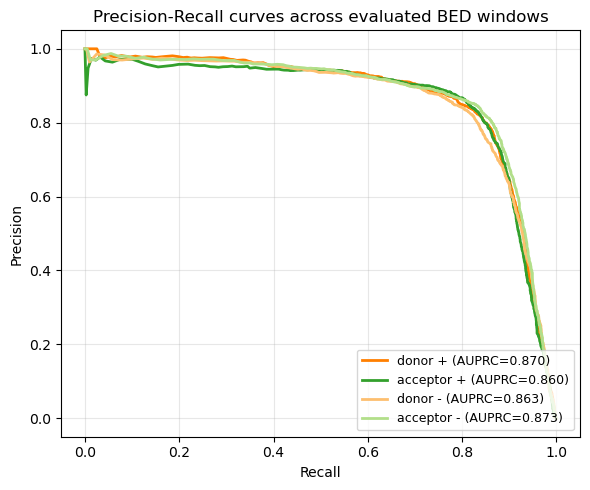

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

for cls_idx in range(len(SPLICE_CLASS_NAMES)):
    binary = (all_true_classes == cls_idx).astype(int)
    if binary.sum() == 0:
        continue
    prec, rec, _ = precision_recall_curve(binary, all_probs[:, cls_idx])
    auprc = average_precision_score(binary, all_probs[:, cls_idx])
    ax.plot(rec, prec, color=CLASS_COLORS[cls_idx], lw=2,
            label=f"{CLASS_LABELS[cls_idx]} (AUPRC={auprc:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])
ax.grid(alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
ax.set_title("Precision-Recall curves across evaluated BED windows")
plt.tight_layout()
plt.show()

## Usage alpha: correct vs incorrect predictions

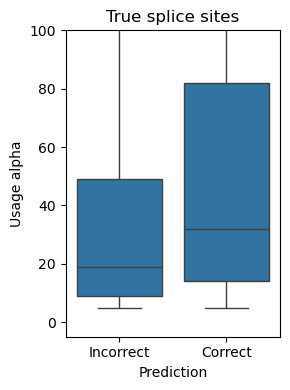

In [ ]:
if all_alphas:
    import seaborn as sns
    alpha_df = pd.DataFrame(all_alphas).dropna(subset=["alpha"])
    # Only keep sites where the true label is not background
    if len(all_true_classes) == len(alpha_df):
        mask = all_true_classes != BACKGROUND_CLASS
        alpha_df = alpha_df[mask]
    fig, ax = plt.subplots(figsize=(3, 4))
    sns.boxplot(x="correct", y="alpha", data=alpha_df, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_ylim(-5, 100)
    ax.set_xticklabels(["Incorrect", "Correct"])
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Usage alpha")
    ax.set_title("True splice sites")
    plt.tight_layout()
    plt.show()
else:
    print("No usage alpha data collected (check usage_file path or column names)")

## Splice usage correlation

Runs the finetuned usage head on 1bp embeddings and compares predicted usage
(sigmoid output) to observed SSE (Alpha / (Alpha + Beta)) from the usage parquet.
Works only when a finetuned checkpoint with usage heads is loaded.


In [ ]:
from tqdm.auto import tqdm
from scipy.stats import pearsonr, spearmanr

usage_heads_dict = (cfg or {}).get("_usage_heads", {})
usage_head_eval  = usage_heads_dict.get(organism)

if usage_head_eval is None:
    print("No usage head found for organism", organism,
          "— load a finetuned checkpoint that includes a usage head.")
else:
    n_conditions = (cfg or {}).get("species_n_conditions", {}).get(str(organism), 0)
    print(f"Usage head: {n_conditions} conditions (organism={organism})")

    org_t = torch.full((1,), organism, dtype=torch.long, device=device)
    usage_head_eval.eval()

    # How many windows to use (can be slow; cap at 100 by default)
    max_usage_windows = min(100, len(windows))

    # Min coverage filter matching evaluate_splice.py (Alpha + Beta >= 10)
    MIN_COVERAGE = 10

    records = []  # list of {pred_usage, obs_sse, site_type}

    label_to_sitetype = {0: "Donor+", 1: "Acceptor+", 2: "Donor-", 3: "Acceptor-"}

    # Model was trained with bfloat16 AMP; use autocast to match
    use_bf16 = (cfg or {}).get("dtype", "bfloat16") == "bfloat16"
    autocast_ctx = torch.amp.autocast(device_type=device, dtype=torch.bfloat16, enabled=use_bf16)

    with torch.no_grad(), autocast_ctx:
        for chrom_w, start_w, end_w in tqdm(windows[:max_usage_windows], desc="Usage windows"):
            try:
                seq = fasta[chrom_w][start_w:end_w]
            except Exception:
                continue
            if len(seq) != seq_len:
                continue

            seq_np = sequence_to_onehot(seq).astype(np.float32)
            seq_t  = torch.from_numpy(seq_np).unsqueeze(0).to(device)

            # Get 1bp embeddings in NCL format (needed by usage head)
            fwd     = model.forward(seq_t, org_t, embeddings_only=True, channels_last=False)
            emb_1bp = fwd["embeddings_1bp"]  # (1, C, S) NCL

            usage_out  = usage_head_eval(emb_1bp, org_t, channels_last=True)
            pred_usage = usage_out["predictions"][0].float().cpu().numpy()  # (S, T)

            chrom_str = str(chrom_w)
            # usage.parquet stores 1-based positions; convert to 0-based with -1
            # Apply min-coverage filter (Alpha + Beta >= MIN_COVERAGE) matching evaluate_splice.py
            w_usage = usage[
                (usage["Chromosome"] == chrom_str) &
                (usage["Position"] - 1 >= start_w) &
                (usage["Position"] - 1 <  end_w) &
                (usage["Label"] != 4) &                    # exclude background
                (usage["Alpha"] + usage["Beta"] >= MIN_COVERAGE)  # coverage filter
            ]

            for _, row in w_usage.iterrows():
                rel  = int(row["Position"]) - 1 - start_w  # convert 1-based → 0-based, then relative
                cond = int(row["Condition"])
                if 0 <= rel < seq_len and cond < n_conditions:
                    # Do NOT filter on SSE; include all sites with coverage
                    records.append({
                        "pred_usage": float(pred_usage[rel, cond]),
                        "obs_sse":    float(row["SSE"]),
                        "site_type":  label_to_sitetype.get(int(row["Label"]), "Unknown"),
                    })

    usage_corr_df = pd.DataFrame(records)
    print(f"\nCollected {len(usage_corr_df)} site-condition pairs from {max_usage_windows} windows")
    if len(usage_corr_df) > 1:
        r_p, _ = pearsonr(usage_corr_df["obs_sse"], usage_corr_df["pred_usage"])
        r_s, _ = spearmanr(usage_corr_df["obs_sse"], usage_corr_df["pred_usage"])
        print(f"Overall  — Pearson r={r_p:.3f}  Spearman r={r_s:.3f}")
        for st, grp in usage_corr_df.groupby("site_type"):
            if len(grp) > 1:
                rp2, _ = pearsonr(grp["obs_sse"], grp["pred_usage"])
                rs2, _ = spearmanr(grp["obs_sse"], grp["pred_usage"])
                print(f"  {st:<14} n={len(grp):>6}  Pearson r={rp2:.3f}  Spearman r={rs2:.3f}")


/sasselab3/home/elek/miniforge3/envs/alphagenome_pytorch_genomicsxai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Usage head: 62 conditions (organism=0)


Usage windows: 100%|██████████| 100/100 [01:29<00:00,  1.11it/s]


Collected 165277 site-condition pairs from 100 windows
Overall  — Pearson r=0.538  Spearman r=0.240
  Acceptor+      n= 37688  Pearson r=0.503  Spearman r=0.249
  Acceptor-      n= 45893  Pearson r=0.542  Spearman r=0.192
  Donor+         n= 36445  Pearson r=0.523  Spearman r=0.229
  Donor-         n= 45251  Pearson r=0.575  Spearman r=0.224


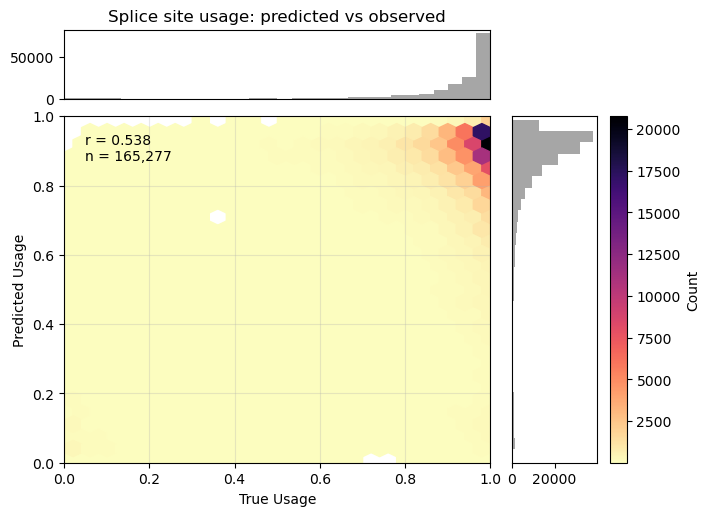

: 

In [ ]:
import matplotlib.pyplot as plt

if "usage_corr_df" not in dir() or len(usage_corr_df) == 0:
    print("No usage correlation data — run the cell above first.")
else:
    true_all = usage_corr_df["obs_sse"].to_numpy(dtype="float32")
    pred_all = usage_corr_df["pred_usage"].to_numpy(dtype="float32")

    fig, ax = plt.subplots(figsize=(5.5, 4.5))

    hb = ax.hexbin(true_all, pred_all, gridsize=25, cmap="magma_r", mincnt=1)

    num_points = len(true_all)
    if true_all.std() > 1e-8 and pred_all.std() > 1e-8:
        corr = float(np.corrcoef(true_all, pred_all)[0, 1])
        ax.text(0.05, 0.95, f"r = {corr:.3f}\nn = {num_points:,}",
                transform=ax.transAxes, fontsize=10, verticalalignment="top")

    # Marginal histograms
    ax_histx = ax.inset_axes([0, 1.05, 1, 0.2], sharex=ax)
    ax_histx.hist(true_all, bins=30, color="gray", alpha=0.7)
    ax_histx.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    ax_histy = ax.inset_axes([1.05, 0, 0.2, 1], sharey=ax)
    ax_histy.hist(pred_all, bins=30, orientation="horizontal", color="gray", alpha=0.7)
    ax_histy.tick_params(axis="y", which="both", left=False, right=False, labelleft=False)

    cax = ax.inset_axes([1.28, 0, 0.04, 1])
    fig.colorbar(hb, cax=cax, label="Count")

    ax.set_xlabel("True Usage")
    ax.set_ylabel("Predicted Usage")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title("Splice site usage: predicted vs observed")
    ax.grid(True, alpha=0.3)

    plt.show()
